# Classificazione Patologie ECG con CNN Embedded
### Tentativo 5: RR interval ausiliario + data augmentation su F

**Dataset**: MIT-BIH Arrhythmia Database (PhysioNet)
**Approccio**: raw signal + RR interval, nessuna feature morfologica calcolata a mano
**Modifiche rispetto ai tentativi precedenti**: input duale (forma d'onda + RR interval) per attaccare la debolezza su S; augmentation label-preserving (jitter, rumore, scaling) sui soli esempi reali di F per attaccarne la scarsita'

## 0. Avvio rapido (se il dataset e' gia' stato salvato su Drive, versione con RR interval)

Richiede il nuovo salvataggio (Sezione 6bis aggiornata) che include anche gli array RR interval. Se hai solo il salvataggio precedente (senza RR), riesegui dalla Sezione 1.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt

SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'

X_train = np.load(f'{SALVA_DIR}/X_train.npy')
y_train = np.load(f'{SALVA_DIR}/y_train.npy')
rr_train = np.load(f'{SALVA_DIR}/rr_train.npy')
X_val = np.load(f'{SALVA_DIR}/X_val.npy')
y_val = np.load(f'{SALVA_DIR}/y_val.npy')
rr_val = np.load(f'{SALVA_DIR}/rr_val.npy')
X_test = np.load(f'{SALVA_DIR}/X_test.npy')
y_test = np.load(f'{SALVA_DIR}/y_test.npy')
rr_test = np.load(f'{SALVA_DIR}/rr_test.npy')

print('Dataset (con RR interval) ricaricato da Drive:')
print(f'Training:   {X_train.shape}, RR: {rr_train.shape}')
print(f'Validation: {X_val.shape}, RR: {rr_val.shape}')
print(f'Test:       {X_test.shape}, RR: {rr_test.shape}')

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ecg_project_data/rr_train.npy'

## 1. Setup ambiente

In [2]:
!pip install wfdb -q

import wfdb
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.7 MB/s eta 0:00:00


## 2. Download completo del dataset (48 record) + mappatura AAMI

In [3]:
record_names = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

aami_map = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',
    'V': 'V', 'E': 'V',
    'F': 'F',
    '/': 'Q', 'f': 'Q', 'Q': 'Q'
}

dataset = {}

for rec_name in record_names:
    record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
    ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')

    campioni_validi = []
    classi_valide = []
    for campione, simbolo in zip(ann.sample, ann.symbol):
        if simbolo in aami_map:
            campioni_validi.append(campione)
            classi_valide.append(aami_map[simbolo])

    dataset[rec_name] = {
        'signal': record.p_signal,
        'fs': record.fs,
        'beat_samples': np.array(campioni_validi),
        'beat_labels': np.array(classi_valide)
    }
    print(f'Record {rec_name}: {len(campioni_validi)} battiti validi')

print(f'\nTutti i {len(record_names)} record scaricati')

Record 100: 2273 battiti validi
Record 101: 1865 battiti validi
Record 102: 2187 battiti validi
Record 103: 2084 battiti validi
Record 104: 2229 battiti validi
Record 105: 2572 battiti validi
Record 106: 2027 battiti validi
Record 107: 2137 battiti validi
Record 108: 1763 battiti validi
Record 109: 2532 battiti validi
Record 111: 2124 battiti validi
Record 112: 2539 battiti validi
Record 113: 1795 battiti validi
Record 114: 1879 battiti validi
Record 115: 1953 battiti validi
Record 116: 2412 battiti validi
Record 117: 1535 battiti validi
Record 118: 2278 battiti validi
Record 119: 1987 battiti validi
Record 121: 1863 battiti validi
Record 122: 2476 battiti validi
Record 123: 1518 battiti validi
Record 124: 1619 battiti validi
Record 200: 2601 battiti validi
Record 201: 1963 battiti validi
Record 202: 2136 battiti validi
Record 203: 2980 battiti validi
Record 205: 2656 battiti validi
Record 207: 1860 battiti validi
Record 208: 2955 battiti validi
Record 209: 3005 battiti validi
Record 2

## 3. Preprocessing: filtro passa-banda

In [4]:
from scipy.signal import butter, filtfilt

CANALE = 0

def filtro_passabanda(segnale, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, segnale)

for rec_name in dataset:
    segnale_grezzo = dataset[rec_name]['signal'][:, CANALE]
    dataset[rec_name]['signal_filtered'] = filtro_passabanda(segnale_grezzo, dataset[rec_name]['fs'])

print('Filtro passa-banda applicato a tutti i record.')

Filtro passa-banda applicato a tutti i record.


## 4. Segmentazione + calcolo RR interval

Novita' rispetto ai tentativi precedenti: per ogni battito calcoliamo anche l'**RR interval** (distanza in campioni dal battito precedente nello stesso record). Il primo battito di ogni record non ha un precedente: gli assegniamo l'RR interval mediano del record stesso (valore neutro, non zero, per non introdurre un falso segnale di 'battito molto prematuro').

In [5]:
FINESTRA_PRIMA = 100
FINESTRA_DOPO = 200

X = []
y = []
record_id = []
beat_position = []
rr_interval = []

for rec_name in dataset:
    segnale = dataset[rec_name]['signal_filtered']
    campioni_battiti = dataset[rec_name]['beat_samples']
    classi_battiti = dataset[rec_name]['beat_labels']

    diff_rr = np.diff(campioni_battiti)
    rr_mediano = np.median(diff_rr) if len(diff_rr) > 0 else 0

    for idx, (campione, classe) in enumerate(zip(campioni_battiti, classi_battiti)):
        inizio = campione - FINESTRA_PRIMA
        fine = campione + FINESTRA_DOPO
        if inizio < 0 or fine > len(segnale):
            continue

        segmento = segnale[inizio:fine]
        media = np.mean(segmento)
        std = np.std(segmento)
        segmento_normalizzato = (segmento - media) / (std + 1e-8)

        rr = (campione - campioni_battiti[idx - 1]) if idx > 0 else rr_mediano

        X.append(segmento_normalizzato)
        y.append(classe)
        record_id.append(rec_name)
        beat_position.append(campione)
        rr_interval.append(rr)

X = np.array(X)
y = np.array(y)
record_id = np.array(record_id)
beat_position = np.array(beat_position)
rr_interval = np.array(rr_interval, dtype=float)

print(f'Segmenti totali estratti: {len(X)}')
print(f'RR interval - min/mediana/max: {rr_interval.min():.0f} / {np.median(rr_interval):.0f} / {rr_interval.max():.0f} campioni')

Segmenti totali estratti: 109446
RR interval - min/mediana/max: 90 / 275 / 36008 campioni


## 5. Split Train / Validation / Test per paziente

In [6]:
from sklearn.model_selection import train_test_split

record_unici = np.array(record_names)
record_train, record_valtest = train_test_split(record_unici, test_size=0.30, random_state=42)
record_val, record_test = train_test_split(record_valtest, test_size=0.50, random_state=42)

mask_train = np.isin(record_id, record_train)
mask_val = np.isin(record_id, record_val)
mask_test = np.isin(record_id, record_test)

X_train, y_train, rr_train = X[mask_train], y[mask_train], rr_interval[mask_train]
X_val, y_val, rr_val = X[mask_val], y[mask_val], rr_interval[mask_val]
X_test, y_test, rr_test = X[mask_test], y[mask_test], rr_interval[mask_test]

print(f'Training:   {X_train.shape[0]} segmenti')
print(f'Validation: {X_val.shape[0]} segmenti')
print(f'Test:       {X_test.shape[0]} segmenti')

Training:   75395 segmenti
Validation: 14911 segmenti
Test:       19140 segmenti


## 5bis. Salvataggio su Google Drive (versione con RR interval)

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import os
SALVA_DIR = '/content/drive/MyDrive/ecg_project_data'
os.makedirs(SALVA_DIR, exist_ok=True)

np.save(f'{SALVA_DIR}/X_train.npy', X_train)
np.save(f'{SALVA_DIR}/y_train.npy', y_train)
np.save(f'{SALVA_DIR}/rr_train.npy', rr_train)
np.save(f'{SALVA_DIR}/X_val.npy', X_val)
np.save(f'{SALVA_DIR}/y_val.npy', y_val)
np.save(f'{SALVA_DIR}/rr_val.npy', rr_val)
np.save(f'{SALVA_DIR}/X_test.npy', X_test)
np.save(f'{SALVA_DIR}/y_test.npy', y_test)
np.save(f'{SALVA_DIR}/rr_test.npy', rr_test)

print('Dataset (con RR interval) salvato su Google Drive in:', SALVA_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset (con RR interval) salvato su Google Drive in: /content/drive/MyDrive/ecg_project_data


## 6. Codifica etichette, normalizzazione RR interval, reshape

In [8]:
classe_to_int = {classe: i for i, classe in enumerate(sorted(np.unique(np.concatenate([y_train, y_val, y_test]))))}
int_to_classe = {i: classe for classe, i in classe_to_int.items()}
num_classi = len(classe_to_int)
print('Mappa classi -> interi:', classe_to_int)

y_train_int = np.array([classe_to_int[c] for c in y_train])
y_val_int = np.array([classe_to_int[c] for c in y_val])
y_test_int = np.array([classe_to_int[c] for c in y_test])

# Normalizzazione RR interval: statistiche calcolate SOLO sul training (evita leakage)
rr_media = rr_train.mean()
rr_std = rr_train.std()

rr_train_norm = (rr_train - rr_media) / (rr_std + 1e-8)
rr_val_norm = (rr_val - rr_media) / (rr_std + 1e-8)
rr_test_norm = (rr_test - rr_media) / (rr_std + 1e-8)

X_train_r = X_train.reshape(-1, X_train.shape[1], 1)
X_val_r = X_val.reshape(-1, X_val.shape[1], 1)
X_test_r = X_test.reshape(-1, X_test.shape[1], 1)

print(f'Forma X_train: {X_train_r.shape}, RR train: {rr_train_norm.shape}')

Mappa classi -> interi: {np.str_('F'): 0, np.str_('N'): 1, np.str_('Q'): 2, np.str_('S'): 3, np.str_('V'): 4}
Forma X_train: (75395, 300, 1), RR train: (75395,)


## 7. Data augmentation mirata sulla classe F (solo training set)

Generiamo varianti sintetiche label-preserving dei soli esempi reali di F nel training set: jitter temporale (+/- 5 campioni), rumore gaussiano lieve, scaling di ampiezza (0.9-1.1x). Nessuna perturbazione su validation/test: devono restare dati reali intatti per una valutazione onesta.

In [9]:
def augmenta_segmento(segmento, rng):
    aug = segmento.copy()

    # Jitter temporale: shift circolare di pochi campioni
    shift = rng.integers(-5, 6)
    aug = np.roll(aug, shift)

    # Rumore gaussiano lieve (deviazione standard contenuta rispetto al segnale normalizzato)
    aug = aug + rng.normal(0, 0.03, size=aug.shape)

    # Scaling di ampiezza
    fattore_scala = rng.uniform(0.9, 1.1)
    aug = aug * fattore_scala

    return aug

rng = np.random.default_rng(42)

indice_F = classe_to_int['F']
idx_F_train = np.where(y_train_int == indice_F)[0]
print(f'Esempi reali di F nel training: {len(idx_F_train)}')

N_COPIE_PER_ESEMPIO = 8  # 422 * 8 = ~3376 esempi sintetici aggiuntivi

X_aug_list = []
rr_aug_list = []
y_aug_list = []

for idx in idx_F_train:
    segmento_originale = X_train_r[idx, :, 0]
    rr_originale = rr_train_norm[idx]
    for _ in range(N_COPIE_PER_ESEMPIO):
        X_aug_list.append(augmenta_segmento(segmento_originale, rng))
        rr_aug_list.append(rr_originale)  # RR interval non perturbato: resta un dato temporale reale
        y_aug_list.append(indice_F)

X_aug = np.array(X_aug_list).reshape(-1, X_train_r.shape[1], 1)
rr_aug = np.array(rr_aug_list)
y_aug = np.array(y_aug_list)

X_train_final = np.concatenate([X_train_r, X_aug], axis=0)
rr_train_final = np.concatenate([rr_train_norm, rr_aug], axis=0)
y_train_final = np.concatenate([y_train_int, y_aug], axis=0)

print(f'Training dopo augmentation: {len(y_train_final)} esempi totali')
print(f'Esempi di F dopo augmentation: {(y_train_final == indice_F).sum()}')

Esempi reali di F nel training: 422
Training dopo augmentation: 78771 esempi totali
Esempi di F dopo augmentation: 3798


## 8. Architettura a doppio input: forma d'onda + RR interval

API funzionale Keras: un ramo convoluzionale sulla forma d'onda (come nei tentativi precedenti) e un piccolo ramo denso sull'RR interval, uniti prima della classificazione finale.

In [10]:
from tensorflow.keras import layers, models, Input

def costruisci_modello_duale(lunghezza_finestra, num_classi):
    input_forma = Input(shape=(lunghezza_finestra, 1), name='forma_donda')
    x = layers.Conv1D(16, kernel_size=9, padding='same')(input_forma)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(32, kernel_size=7, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(64, kernel_size=5, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling1D()(x)

    input_rr = Input(shape=(1,), name='rr_interval')
    r = layers.Dense(16, activation='relu')(input_rr)
    r = layers.Dense(8, activation='relu')(r)

    combinato = layers.Concatenate()([x, r])
    output = layers.Dense(num_classi, activation='softmax')(combinato)

    model = models.Model(inputs=[input_forma, input_rr], outputs=output)
    return model

model = costruisci_modello_duale(X_train_r.shape[1], num_classi)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ forma_donda         │ (None, 300, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 16)   │        160 │ forma_donda[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 16)   │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 300, 16)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 150, 16)   │          0 │ re_lu[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 150, 32)   │      3,616 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 150, 32)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 75, 32)    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 75, 64)    │     10,304 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr_interval         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 75, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         32 │ rr_interval[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ re_lu_2[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │        136 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 72)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 5)         │        365 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,061 (58.83 KB)

 Trainable params: 14,837 (57.96 KB)

 Non-trainable params: 224 (896.00 B)

## 9. Training

Class weights bilanciati (senza capping estremo: l'augmentation ha gia' ridotto lo sbilanciamento assoluto di F).

In [11]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

pesi = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_final), y=y_train_final)
class_weights_dict = dict(zip(np.unique(y_train_final), pesi))
print('Class weights (post-augmentation):', class_weights_dict)

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history = model.fit(
    [X_train_final, rr_train_final], y_train_final,
    validation_data=([X_val_r, rr_val_norm], y_val_int),
    epochs=60,
    batch_size=64,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Class weights (post-augmentation): {np.int64(0): np.float64(4.148025276461295), np.int64(1): np.float64(0.25665830373725196), np.int64(2): np.float64(2.6375690607734805), np.int64(3): np.float64(6.7440924657534245), np.int64(4): np.float64(2.9826202196137825)}
Epoch 1/60
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 83s 60ms/step - accuracy: 0.7587 - loss: 0.5080 - val_accuracy: 0.8409 - val_loss: 0.5960 - learning_rate: 3.0000e-04
Epoch 2/60
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 70s 57ms/step - accuracy: 0.9374 - loss: 0.2123 - val_accuracy: 0.9427 - val_loss: 0.2510 - learning_rate: 3.0000e-04
Epoch 3/60
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 85s 59ms/step - accuracy: 0.9515 - loss: 0.1685 - val_accuracy: 0.9201 - val_loss: 0.3448 - learning_rate: 3.0000e-04
Epoch 4/60
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 69s 56ms/step - accuracy: 0.9570 - loss: 0.1495 - val_accuracy: 0.9178 - val_loss: 0.3133 - learning_rate: 3.0000e-04
Epoch 5/60
1231/1231 ━━━━━━━━━━━━━━━━━━━━ 72s 59ms/step - accuracy: 0.9605 - loss: 0.1360 - val_acc

## 10. Valutazione su Validation Set

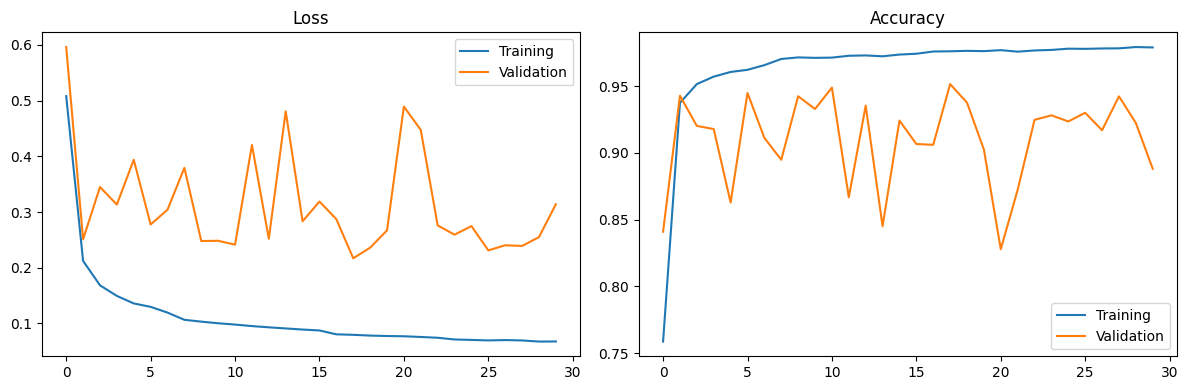

466/466 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step


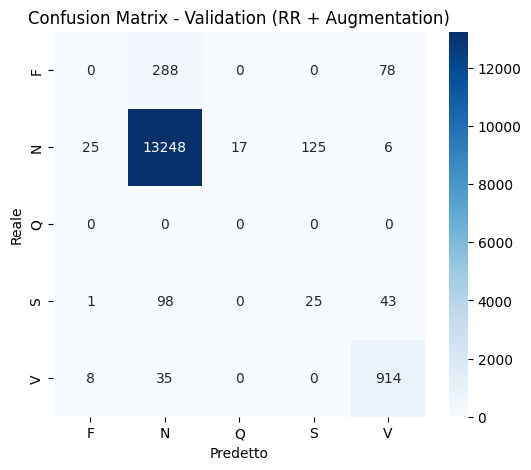

              precision    recall  f1-score   support

           F       0.00      0.00      0.00       366
           N       0.97      0.99      0.98     13421
           Q       0.00      0.00      0.00         0
           S       0.17      0.15      0.16       167
           V       0.88      0.96      0.91       957

    accuracy                           0.95     14911
   macro avg       0.40      0.42      0.41     14911
weighted avg       0.93      0.95      0.94     14911

Macro F1: 0.4101433422481035


In [12]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss')
axes[0].legend()
axes[1].plot(history.history['accuracy'], label='Training')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

y_val_pred = np.argmax(model.predict([X_val_r, rr_val_norm]), axis=1)
nomi_classi = [int_to_classe[i] for i in range(num_classi)]

cm = confusion_matrix(y_val_int, y_val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nomi_classi, yticklabels=nomi_classi, cmap='Blues')
plt.xlabel('Predetto'); plt.ylabel('Reale'); plt.title('Confusion Matrix - Validation (RR + Augmentation)')
plt.show()

print(classification_report(y_val_int, y_val_pred, target_names=nomi_classi, zero_division=0))
print('Macro F1:', f1_score(y_val_int, y_val_pred, average='macro', zero_division=0))